c:\Users\plui0\EKGenie\EKGenie
['.git', 'Arduino.cpp', 'BidirectionalLSTM.ipynb', 'CleanData.ipynb', 'CNN.ipynb', 'DataVisualization.ipynb', 'EKGenie Midterm Presentation.pptx', 'FeatureEngineering.ipynb', 'GRU.ipynb', 'ML_Other.ipynb', 'ML_Test.ipynb', 'naiveBayes.ipynb', 'README.md', 'RNN.ipynb', 'Window.py']
Class weights: {0: np.float64(0.21844403630934292), 1: np.float64(7.4370220422852), 2: np.float64(2.8563407049067036), 3: np.float64(25.79173166926677), 4: np.float64(2.570751049603483), 5: np.float64(1.9613833194922292)}
Epoch 1/10


c:\Users\plui0\anaconda3\envs\tfcpu\lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


3100/3100 ━━━━━━━━━━━━━━━━━━━━ 74s 23ms/step - accuracy: 0.1194 - loss: 1.6075 - val_accuracy: 0.2221 - val_loss: 1.4355
Epoch 2/10
3100/3100 ━━━━━━━━━━━━━━━━━━━━ 75s 24ms/step - accuracy: 0.2408 - loss: 1.2287 - val_accuracy: 0.4336 - val_loss: 1.2868
Epoch 3/10
3100/3100 ━━━━━━━━━━━━━━━━━━━━ 77s 25ms/step - accuracy: 0.4310 - loss: 0.9116 - val_accuracy: 0.4857 - val_loss: 1.1241
Epoch 4/10
3100/3100 ━━━━━━━━━━━━━━━━━━━━ 80s 26ms/step - accuracy: 0.5239 - loss: 0.7482 - val_accuracy: 0.6037 - val_loss: 0.9013
Epoch 5/10
3100/3100 ━━━━━━━━━━━━━━━━━━━━ 81s 26ms/step - accuracy: 0.5966 - loss: 0.6284 - val_accuracy: 0.6358 - val_loss: 0.8127
Epoch 6/10
3100/3100 ━━━━━━━━━━━━━━━━━━━━ 87s 28ms/step - accuracy: 0.6493 - loss: 0.5451 - val_accuracy: 0.6913 - val_loss: 0.7346
Epoch 7/10
3100/3100 ━━━━━━━━━━━━━━━━━━━━ 88s 28ms/step - accuracy: 0.6845 - loss: 0.5028 - val_accuracy: 0.7272 - val_loss: 0.7036
Epoch 8/10
3100/3100 ━━━━━━━━━━━━━━━━━━━━ 90s 29ms/step - accuracy: 0.7264 - loss: 0.45

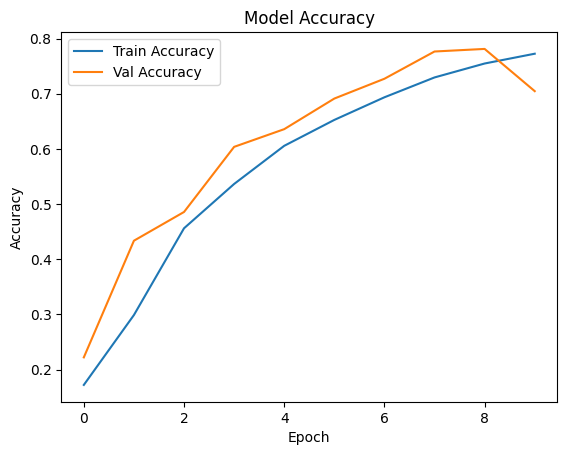

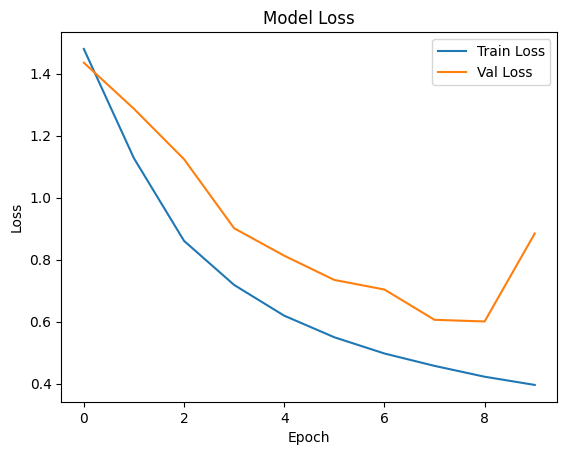

776/776 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step


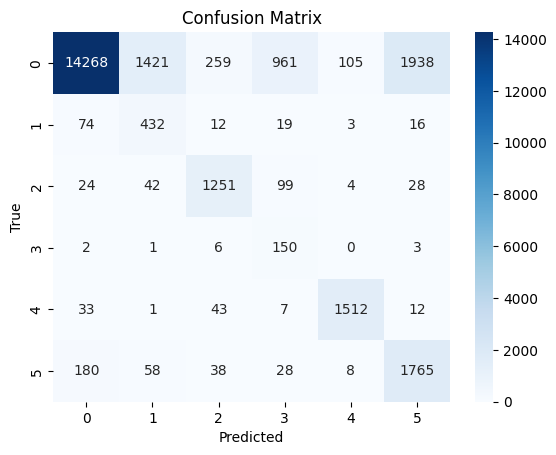

              precision    recall  f1-score   support

           0       0.98      0.75      0.85     18952
           1       0.22      0.78      0.34       556
           2       0.78      0.86      0.82      1448
           3       0.12      0.93      0.21       162
           4       0.93      0.94      0.93      1608
           5       0.47      0.85      0.60      2077

    accuracy                           0.78     24803
   macro avg       0.58      0.85      0.63     24803
weighted avg       0.90      0.78      0.82     24803



In [2]:
 %run CleanData.ipynb

import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.losses import CategoricalCrossentropy
import joblib
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, GRU, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from sklearn.utils.class_weight import compute_class_weight

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

#reshape the train and test sets to 3D — which is required by GRUs ([samples, timesteps, features]).
import os
print(os.getcwd())
print(os.listdir())
# X_train, X_test, y_train, y_test = joblib.load("ecg_split_data.pkl")
X_train = X_train.values.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.values.reshape((X_test.shape[0], X_test.shape[1], 1))
y_train = to_categorical(y_train, num_classes=6)
y_test = to_categorical(y_test, num_classes=6)
import numpy as np
np.bincount(np.argmax(y_train, axis=1))

# Convert from one-hot to int labels
y_train_int = np.argmax(y_train, axis=1)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_int),
    y=y_train_int
)

class_weights = dict(enumerate(class_weights))
print("Class weights:", class_weights)
model = Sequential([
    GRU(64, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dense(6, activation='softmax')
])
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=CategoricalCrossentropy(),
    metrics=['accuracy']
)
# Optional: Add early stopping to prevent overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
# Train the model
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    class_weight=class_weights,
    verbose=1
)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()



# Predict classes
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# Classification report
print(classification_report(y_true_classes, y_pred_classes))

C:\Users\plui0\AppData\Local\Temp\ipykernel_27764\4199253349.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', num_classes)


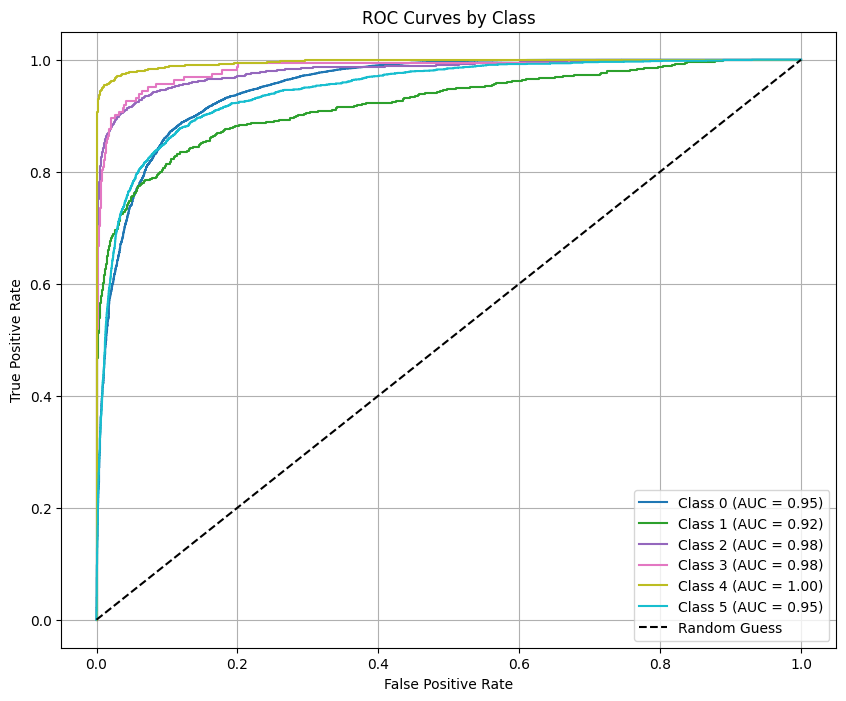

In [5]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Number of classes
num_classes = y_test.shape[1]

# Compute ROC curve and AUC for each class
fpr = {}
tpr = {}
roc_auc = {}

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(10, 8))
colors = plt.cm.get_cmap('tab10', num_classes)

for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.2f})", color=colors(i))

plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves by Class")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()
